<a href="https://colab.research.google.com/github/00015775/learning-lab/blob/learn%2Fpytorch/pytorch/notebooks/mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import numpy as np
import matplotlib.pyplot as plt

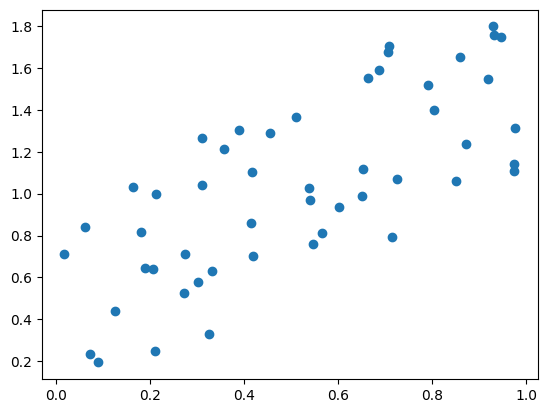

In [2]:
N = 50

X = np.random.random(N)
y = X + np.random.random(N)

plt.scatter(X, y)

In [3]:
np.random.seed(42)

N = 20

X = np.random.random(N)*10-5
y = 0.5*X - 1 + np.random.random(N)

In [4]:
X, X.shape

(array([-1.25459881,  4.50714306,  2.31993942,  0.98658484, -3.4398136 ,
        -3.4400548 , -4.41916388,  3.66176146,  1.01115012,  2.08072578,
        -4.79415506,  4.69909852,  3.32442641, -2.87660889, -3.18175033,
        -3.1659549 , -1.95757757,  0.24756432, -0.68054981, -2.0877086 ]),
 (20,))

In [5]:
y, y.shape

(array([-1.01544651,  1.39306539,  0.45211436, -0.14034574, -2.26383681,
        -1.93485144, -3.00990816,  1.34511517,  0.09798963,  0.0868133 ,
        -2.78953268,  1.52007338,  0.7272648 , -1.48941891, -1.62524313,
        -1.7745801 , -1.67417502, -0.77854573, -0.65604188, -1.60370181]),
 (20,))

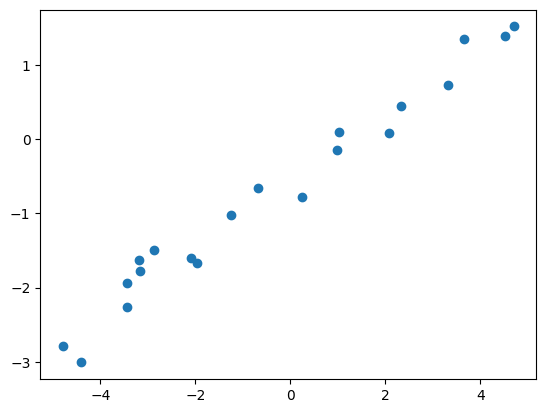

In [6]:
plt.scatter(X, y)

In [7]:
model = nn.Linear(1,1)

In [8]:
model

Linear(in_features=1, out_features=1, bias=True)

In [9]:
model.weight.data, model.bias.data

(tensor([[0.8958]]), tensor([0.4822]))

In [10]:
w_0 = model.weight.data.numpy()
b_0 = model.bias.data.numpy()
print(w_0, b_0)

[[0.89581203]] [0.482244]


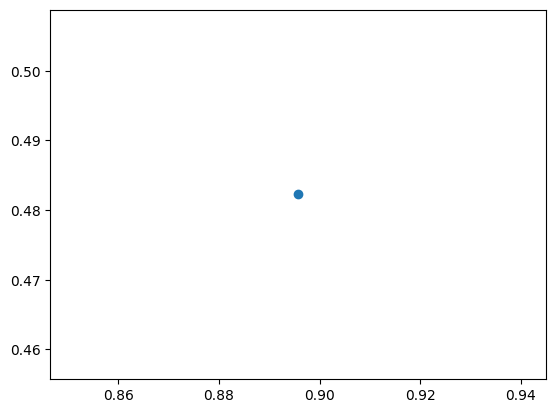

In [11]:
plt.scatter(w_0, b_0)

In [12]:
X.shape, y.shape

((20,), (20,))

In [13]:
X = X.reshape(N, 1)
y = y.reshape(N, 1)

X.shape, y.shape

((20, 1), (20, 1))

In [14]:
type(X), type(y)

(numpy.ndarray, numpy.ndarray)

In [15]:
inputs = torch.from_numpy(X.astype(np.float32))
targets = torch.from_numpy(y.astype(np.float32))

In [16]:
inputs.shape, targets.shape

(torch.Size([20, 1]), torch.Size([20, 1]))

In [17]:
epochs = 1000
losses = []

criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(),
                      lr=0.01)

model.train()
for epoch in range(epochs):
  optimizer.zero_grad()

  outputs = model(inputs)

  loss = criterion(outputs, targets)
  losses.append(loss.item())

  loss.backward()

  optimizer.step()

  model.eval()
  with torch.inference_mode():
    test_pred = model(inputs)
    test_loss = criterion(test_pred, targets)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss.item()} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 2.6265110969543457 | Test Loss: 2.099309206008911
Epoch: 10 | Loss: 0.835854709148407 | Test Loss: 0.7981625199317932
Epoch: 20 | Loss: 0.5638377070426941 | Test Loss: 0.5439016222953796
Epoch: 30 | Loss: 0.3966585397720337 | Test Loss: 0.38332363963127136
Epoch: 40 | Loss: 0.2843252718448639 | Test Loss: 0.2753446698188782
Epoch: 50 | Loss: 0.2086641788482666 | Test Loss: 0.20261502265930176
Epoch: 60 | Loss: 0.157700315117836 | Test Loss: 0.1536256968975067
Epoch: 70 | Loss: 0.1233719140291214 | Test Loss: 0.12062730640172958
Epoch: 80 | Loss: 0.10024891048669815 | Test Loss: 0.09840020537376404
Epoch: 90 | Loss: 0.08467365801334381 | Test Loss: 0.08342842757701874
Epoch: 100 | Loss: 0.07418245077133179 | Test Loss: 0.0733436793088913
Epoch: 110 | Loss: 0.06711576133966446 | Test Loss: 0.06655079126358032
Epoch: 120 | Loss: 0.06235577538609505 | Test Loss: 0.06197519972920418
Epoch: 130 | Loss: 0.05914951115846634 | Test Loss: 0.05889316648244858
Epoch: 140 | Loss: 0

In [18]:
len(losses), max(losses), min(losses)

(1000, 2.6265110969543457, 0.052533190697431564)

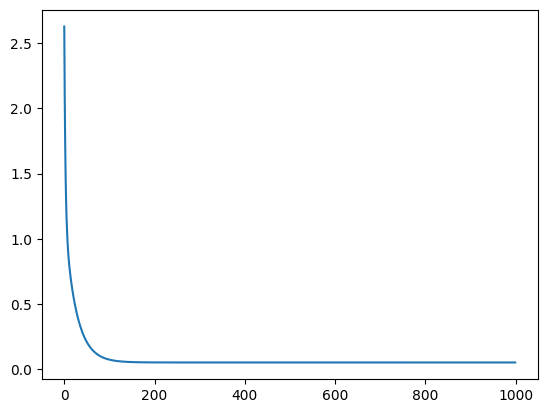

In [19]:
plt.plot(losses)

In [20]:
with torch.inference_mode():
  predictions = model(inputs).detach().numpy() # shares the same storage with tensor
  loss = criterion(torch.from_numpy(predictions.astype(np.float32)), targets)

In [21]:
predictions, predictions.shape

(array([[-1.1260569 ],
        [ 1.4332554 ],
        [ 0.46172   ],
        [-0.1305438 ],
        [-2.096709  ],
        [-2.096816  ],
        [-2.5317273 ],
        [ 1.0577449 ],
        [-0.11963212],
        [ 0.35546345],
        [-2.6982949 ],
        [ 1.5185204 ],
        [ 0.9079038 ],
        [-1.8465387 ],
        [-1.9820796 ],
        [-1.9750634 ],
        [-1.4383135 ],
        [-0.45880988],
        [-0.87106955],
        [-1.4961165 ]], dtype=float32),
 (20, 1))

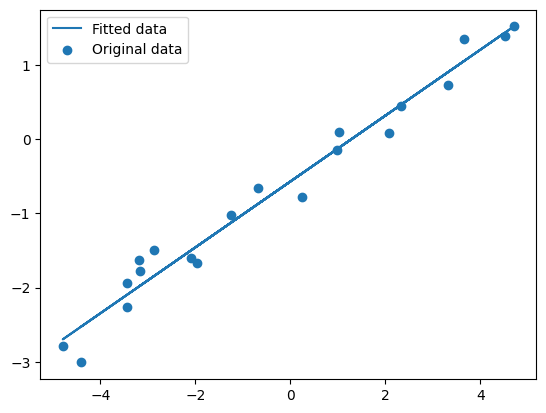

In [22]:
plt.plot(X, predictions, label="Fitted data")
plt.scatter(inputs, targets, label="Original data")
plt.legend()
plt.show()

In [23]:
w = model.weight.data.numpy()
b = model.bias.data.numpy()

print(w, b)

[[0.44419074]] [-0.56877565]


## Handwritten Digit Recognition Model

In [24]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() \
                      else "mps" if torch.backends.mps.is_available() else "cpu")
device

device(type='cuda')

In [26]:
%less /proc/cpuinfo

In [27]:
# parameters and hyperparameters

input_size = 784   # image shape = 28 X 28
hidden_size = 500  # number of hidden layers
num_classes = 10  # 10 digit prediciton outputs
epochs = 50
batch_size = 100
lr = 0.001

In [28]:
# loading dataset
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transforms.ToTensor(), download=True)
test_dataset  = torchvision.datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.4MB/s]


In [29]:
!du -h ./data

64M	./data/MNIST/raw
64M	./data/MNIST
64M	./data


In [30]:
# data loader
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

len(train_loader), len(test_loader)

(600, 100)

In [31]:
feature, label = next(iter(test_loader))

feature.shape, label.shape # need to reshape/flatten image to (B, 784)

(torch.Size([100, 1, 28, 28]), torch.Size([100]))

In [32]:
class NeuralNetwork(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(NeuralNetwork, self).__init__() # also can simply, super()__init__()
    self.l1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.l2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.l1(x)
    out = self.relu(out)
    out = self.l2(out)
    return out

In [33]:
model = NeuralNetwork(input_size=input_size,
                      hidden_size=hidden_size,
                      num_classes=num_classes)

In [34]:
model.to(device)

NeuralNetwork(
  (l1): Linear(in_features=784, out_features=500, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=500, out_features=10, bias=True)
)

In [35]:
import time
starttime = time.time()
x=0
for i in range(100000):
    x+=i
endtime = time.time()
print(f'Job took: {endtime-starttime:.4f} seconds')
if endtime-starttime >= 60:
  print(f'Job took: {endtime-starttime//60:.4f} minutes')

Job took: 0.0106 seconds


In [36]:
import time

start_time = time.time()
losses = []
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),
                       lr=lr)
total_batch_steps = len(train_loader)
model.train()
for epoch in range(epochs):
  for batch_idx, (images, labels) in enumerate(train_loader):
    images = images.reshape(-1, 28*28).to(device)
    labels = labels.to(device)

    outputs = model(images)

    loss = criterion(outputs, labels)
    losses.append(loss.item())

    loss.backward()

    optimizer.step()

    optimizer.zero_grad() # avoids previous batch gradients effecting the current batch

    model.eval()
    with torch.inference_mode():
      test_pred = model(images)
      test_loss = criterion(test_pred, labels)

    if (batch_idx + 1) % 100 == 0:
      print(f"Epoch : [{epoch+1}/{epochs}] | Step: [{batch_idx+1}/{total_batch_steps}] | Loss: {loss.item()} | Test Loss: {test_loss.item()}")

end_time = time.time() - start_time
print(f"Training took: {end_time:.4f} seconds on {device}")
if end_time >= 60:
  print(f"Training took: {end_time//60:.2f} minutes on {device}")


Epoch : [1/50] | Step: [100/600] | Loss: 0.3510798215866089 | Test Loss: 0.3241112232208252
Epoch : [1/50] | Step: [200/600] | Loss: 0.2845173478126526 | Test Loss: 0.26590198278427124
Epoch : [1/50] | Step: [300/600] | Loss: 0.2197730392217636 | Test Loss: 0.18586337566375732
Epoch : [1/50] | Step: [400/600] | Loss: 0.17436474561691284 | Test Loss: 0.17341496050357819
Epoch : [1/50] | Step: [500/600] | Loss: 0.2198719084262848 | Test Loss: 0.19892637431621552
Epoch : [1/50] | Step: [600/600] | Loss: 0.18377012014389038 | Test Loss: 0.1652306169271469
Epoch : [2/50] | Step: [100/600] | Loss: 0.15451262891292572 | Test Loss: 0.13801439106464386
Epoch : [2/50] | Step: [200/600] | Loss: 0.17777390778064728 | Test Loss: 0.15839728713035583
Epoch : [2/50] | Step: [300/600] | Loss: 0.09014200419187546 | Test Loss: 0.08448335528373718
Epoch : [2/50] | Step: [400/600] | Loss: 0.19157519936561584 | Test Loss: 0.17339320480823517
Epoch : [2/50] | Step: [500/600] | Loss: 0.19316905736923218 | Tes

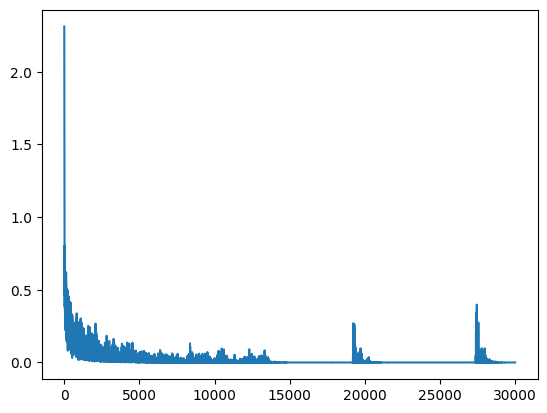

In [37]:
plt.plot(losses)
plt.show()

In [38]:
len(losses), min(losses), max(losses)

(30000, 6.055807943994296e-07, 2.310879707336426)

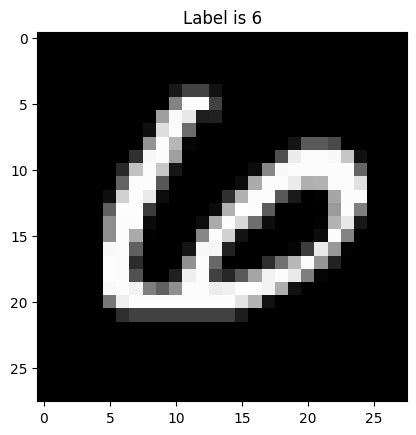

In [39]:
# Source - https://stackoverflow.com/a/37230569
# Posted by bakkal, modified by community. See post 'Timeline' for change history
# Retrieved 2026-01-18, License - CC BY-SA 3.0

import numpy as np
import csv
import matplotlib.pyplot as plt
labels = []

with open('./sample_data/mnist_train_small.csv', 'r') as csv_file:
    for data in csv.reader(csv_file):
        # The first column is the label
        label = data[0]

        # The rest of columns are pixels
        pixels = data[1:]

        # Make those columns into a array of 8-bits pixels
        # This array will be of 1D with length 784
        # The pixel intensity values are integers from 0 to 255
        pixels = np.array(pixels, dtype='uint8')

        # Reshape the array into 28 x 28 array (2-dimensional array)
        pixels = pixels.reshape((28, 28))

        # Plot
        plt.title('Label is {label}'.format(label=label))
        plt.imshow(pixels, cmap='gray')
        plt.show()

        break # This stops the loop, I just want to see one

In [40]:
import numpy as np
import csv
import matplotlib.pyplot as plt
labels = []
with open('./sample_data/mnist_train_small.csv', 'r') as csv_file:
    for data in csv.reader(csv_file):
        # The first column is the label
        label = data[0]
        labels.append(label)
        #break

In [41]:
len(labels)

20000

In [42]:
print(labels)

['6', '5', '7', '9', '5', '2', '0', '6', '5', '5', '2', '7', '7', '6', '8', '9', '3', '5', '7', '6', '9', '4', '3', '4', '9', '2', '9', '1', '3', '9', '7', '7', '5', '8', '6', '1', '7', '2', '7', '8', '8', '7', '1', '3', '7', '4', '1', '1', '9', '2', '9', '2', '0', '9', '7', '8', '2', '0', '2', '6', '3', '5', '6', '2', '8', '6', '5', '6', '2', '6', '8', '8', '7', '0', '4', '0', '8', '8', '7', '9', '9', '0', '3', '1', '2', '7', '2', '1', '1', '2', '4', '2', '1', '0', '2', '8', '3', '2', '3', '2', '7', '6', '2', '7', '1', '6', '2', '0', '7', '0', '2', '2', '0', '6', '7', '7', '7', '2', '3', '7', '3', '1', '9', '3', '7', '5', '0', '6', '7', '7', '7', '6', '6', '6', '2', '8', '1', '3', '1', '4', '7', '2', '2', '1', '5', '9', '3', '3', '4', '3', '5', '3', '0', '5', '2', '9', '2', '8', '9', '4', '2', '8', '2', '7', '0', '6', '2', '0', '8', '9', '4', '6', '2', '4', '7', '2', '7', '4', '1', '3', '5', '0', '0', '1', '4', '1', '5', '6', '1', '3', '8', '9', '7', '8', '3', '8', '4', '8', '6', '5',

In [44]:
!nvidia-smi

Sun Jan 18 08:08:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   63C    P0             28W /   70W |     180MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [47]:
!cat /proc/diskstats

   7       0 loop0 36598 10197 3163018 22364 1592 11186 380712 1384 0 17243 24138 0 0 0 0 211 390
   7       1 loop1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   7       2 loop2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   7       3 loop3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   7       4 loop4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   7       5 loop5 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   7       6 loop6 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   7       7 loop7 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   8       0 sda 52315 4489 5522123 31471 43030 41627 1165524 24733 0 34716 56787 0 0 0 0 13047 582
   8       1 sda1 43623 357 4649724 26052 43024 41627 1165522 24731 0 33282 50784 0 0 0 0 0 0
   8       2 sda2 253 0 6424 96 0 0 0 0 0 80 96 0 0 0 0 0 0
   8       3 sda3 7277 4069 827224 4866 0 0 0 0 0 3525 4866 0 0 0 0 0 0
   8       4 sda4 253 0 6424 99 0 0 0 0 0 79 99 0 0 0 0 0 0
   8       5 sda5 308 0 22880 130 0 0 0 0 0 106 130 0 0 0 0 0 0
   8       6 sda6 11 0 11 3 0 0 0 0 0 4 3 0 0 0 0 0 0
   8       7 sda7 11 0 11 3

In [53]:
!lsblk

NAME    MAJ:MIN RM  SIZE RO TYPE MOUNTPOINTS
loop0     7:0    0  115G  0 loop 
sda       8:0    0   79G  0 disk 
├─sda1    8:1    0 74.8G  0 part /opt/bin/.nvidia
│                                /etc/hosts
│                                /etc/hostname
│                                /etc/resolv.conf
│                                /usr/lib64-nvidia
│                                /kaggle/input
├─sda2    8:2    0   16M  0 part 
├─sda3    8:3    0    2G  0 part 
├─sda4    8:4    0   16M  0 part 
├─sda5    8:5    0    2G  0 part 
├─sda6    8:6    0  512B  0 part 
├─sda7    8:7    0  512B  0 part 
├─sda8    8:8    0   16M  0 part 
├─sda9    8:9    0  512B  0 part 
├─sda10   8:10   0  512B  0 part 
├─sda11   8:11   0    8M  0 part 
└─sda12   8:12   0   32M  0 part 


In [55]:
!lsblk -a

NAME    MAJ:MIN RM  SIZE RO TYPE MOUNTPOINTS
loop0     7:0    0  115G  0 loop 
loop1     7:1    0    0B  0 loop 
loop2     7:2    0    0B  0 loop 
loop3     7:3    0    0B  0 loop 
loop4     7:4    0    0B  0 loop 
loop5     7:5    0    0B  0 loop 
loop6     7:6    0    0B  0 loop 
loop7     7:7    0    0B  0 loop 
sda       8:0    0   79G  0 disk 
├─sda1    8:1    0 74.8G  0 part /opt/bin/.nvidia
│                                /etc/hosts
│                                /etc/hostname
│                                /etc/resolv.conf
│                                /usr/lib64-nvidia
│                                /kaggle/input
├─sda2    8:2    0   16M  0 part 
├─sda3    8:3    0    2G  0 part 
├─sda4    8:4    0   16M  0 part 
├─sda5    8:5    0    2G  0 part 
├─sda6    8:6    0  512B  0 part 
├─sda7    8:7    0  512B  0 part 
├─sda8    8:8    0   16M  0 part 
├─sda9    8:9    0  512B  0 part 
├─sda10   8:10   0  512B  0 part 
├─sda11   8:11   0    8M  0 part 
└─sda12   8:12   0  